# Titanic Advanced Data Cleaning

In this notebook, I clean the Titanic dataset using data quality checks, missing-value strategy, duplicate checks, and feature engineering.

In [153]:
import pandas as pd
import numpy as np

In [154]:
df_raw = pd.read_csv("train.csv")
df = df_raw.copy()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


I created a copy of the original dataset so the raw data stays unchanged.

In [155]:
df.columns = df.columns.str.lower()
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

I standardized the column names to lowercase so they are easier to use in code.

In [156]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

quality_report.sort_values("missing_percent", ascending=False)

,dtype,missing_count,missing_percent,unique_values
cabin,object,687,77.10,147
age,float64,177,19.87,88
embarked,object,2,0.22,3
passengerid,int64,0,0.00,891
survived,int64,0,0.00,2
pclass,int64,0,0.00,3
name,object,0,0.00,891
sex,object,0,0.00,2
sibsp,int64,0,0.00,7
parch,int64,0,0.00,7


This data quality report shows missing values, missing percentage, data types, and number of unique values for each column. I have 3 missing value columns in my dataset (cabin, age and embarked).

In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df[df.duplicated()]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [159]:
df["passengerid"].duplicated().sum()

np.int64(0)

I checked full-row duplicates and duplicate passenger IDs to confirm that each passenger appears only once.

## Missing Value Strategy

Column: age  
Missing percent: 19.87%  
Decision: Fill missing age using median age grouped by sex and pclass (more similar group of people) because group based median is more reasonable than overall median.  




In [160]:
df["age"] = df["age"].fillna(
    df.groupby(["sex", "pclass"])["age"].transform("median")
)


Column: cabin  
Missing percent: 77.10%  
Decision: Extract deck from the first letter, fill missing deck as Unknown, then remove original cabin.  
Reason: The cabin column has too many missing values to use directly, but the first letter may contain useful deck information.

In [161]:
df["deck"] = df["cabin"].str[0]
df["deck"] = df["deck"].fillna("Unknown")

df = df.drop(columns=["cabin"])

In [162]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'embarked', 'deck'],
      dtype='object')

Cabin has many missing values, but the first letter may represent the deck. I extracted deck information before removing the original cabin column.

Column: embarked  
Missing percent: 0.22%  
Decision: Fill missing embarked with the most common value.  
Reason: Only a very small number of values are missing, so using the mode is a simple and reasonable choice.

In [163]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [164]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown


In [165]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = df["family_size"] == 1


df[["sibsp", "parch", "family_size", "is_alone"]].head()

,sibsp,parch,family_size,is_alone
0,1,0,2,False
1,1,0,2,False
2,0,0,1,True
3,1,0,2,False
4,0,0,1,True


Family size may help because passengers traveling alone and passengers traveling with family may have different survival patterns.

## Final Cleaning Summary

In [166]:
final_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

final_report.sort_values("missing_percent", ascending=False)

,dtype,missing_count,missing_percent,unique_values
passengerid,int64,0,0.0,891
survived,int64,0,0.0,2
pclass,int64,0,0.0,3
name,object,0,0.0,891
sex,object,0,0.0,2
age,float64,0,0.0,89
sibsp,int64,0,0.0,7
parch,int64,0,0.0,7
ticket,object,0,0.0,681
fare,float64,0,0.0,248


In [167]:
df.to_csv("titanic_cleaned.csv", index=False)

In [168]:
pd.read_csv("titanic_cleaned.csv").head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,True


## What I learned

Today I learned how to move from basic analysis to proper data cleaning.

The main upgrade was creating a data quality report, checking duplicates, handling missing values with reasoning, extracting useful information from messy columns, and creating new features like family_size and is_alone.

This cleaned dataset is now ready for visualization and deeper analysis.

## Day 2: Validation and Feature Engineering

In [169]:
df = pd.read_csv("titanic_cleaned.csv")
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,True


In [170]:
df.shape

(891, 14)

The cleaned dataset has 891 rows and 14 columns.
The row count is still 891, which means cleaning did not accidentally remove passengers.

In [171]:
df["title"] = df["name"].str.extract(r',\s(.*?)\.')
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,is_alone,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,False,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,False,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,True,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,False,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,True,Mr


In [172]:
df["title"].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

Titles capture useful passenger information beyond the name. Mr, Mrs, Miss, and Master mainly reflect gender, marital status, and age group. Rare titles like Dr, Rev, Col, Sir, and Lady may reflect social role or status, but they appear in very small numbers, so I grouped them as Rare for cleaner analysis.


In [173]:
def group_title(x):
    if x in ["Mr", "Miss", "Mrs", "Master"]:
        return x
    else:
        return "Rare"

df["title_group"] = df["title"].map(group_title)
df["title_group"].value_counts()

title_group
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [174]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,is_alone,title,title_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,False,Mr,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,False,Mrs,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,True,Miss,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,False,Mrs,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,True,Mr,Mr


## Age Group Feature

Age groups to compare survival patterns across different life stages.

In [175]:
bins = [0, 12, 19, 59, 100]
labels = ["Child", "Teen", "Adult", "Senior"]
df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["age_group"].value_counts()

age_group
Adult     701
Teen       95
Child      69
Senior     26
Name: count, dtype: int64

In [176]:
df.groupby("age_group", observed=True)["survived"].mean() * 100

age_group
Child     57.971014
Teen      41.052632
Adult     36.519258
Senior    26.923077
Name: survived, dtype: float64

Note that: Children had the highest survival rate, while seniors had the lowest.

In [177]:
labels = ["Low", "Medium", "High", "Very High"]
df["fare_group"] = pd.qcut(
    df["fare"],
    4, 
    labels = labels,
)
df["fare_group"].value_counts()

fare_group
Medium       224
Low          223
High         222
Very High    222
Name: count, dtype: int64

In [178]:
df.groupby("fare_group", observed=True)["survived"].mean() * 100

fare_group
Low          19.730942
Medium       30.357143
High         45.495495
Very High    58.108108
Name: survived, dtype: float64

Passengers in higher fare groups had higher survival rates. This may be because fare is related to passenger class, wealth, cabin location, and access to lifeboats.

In [179]:
summary_tables = []


df["is_alone"] = df["is_alone"].map({
    True: True, False: False,
    1: True, 0: False,
   
})

df["is_alone_label"] = df["is_alone"].map({True: "Alone", False: "With family"})
df = df.drop(columns = ["is_alone"])

for col in ["sex", "pclass", "is_alone_label", "title_group", "age_group", "fare_group", "embarked", "deck"]:
    temp = df.groupby(col, observed=True)["survived"].mean() * 100
    temp.index = pd.MultiIndex.from_product([[col], temp.index], names=["feature", "category"])
    summary_tables.append(temp)

survival_summary = pd.concat(summary_tables).to_frame(name="survival_rate")
survival_summary


survival_rate
feature        category                  
sex            female           74.203822
               male             18.890815
pclass         1                62.962963
               2                47.282609
               3                24.236253
is_alone_label Alone            30.353818
               With family      50.564972
title_group    Master           57.500000
               Miss             69.780220
               Mr               15.667311
               Mrs              79.200000
               Rare             44.444444
age_group      Child            57.971014
               Teen             41.052632
               Adult            36.519258
               Senior           26.923077
fare_group     Low              19.730942
               Medium           30.357143
               High             45.495495
               Very High        58.108108
embarked       C                55.357143
               Q                38.961039
               S                33.900929
deck           A                46.666667
               B                74.468085
               C                59.322034
               D                75.757576
               E                75.000000
               F                61.538462
               G                50.000000
               T                 0.000000
               Unknown          29.985444

I used a MultiIndex summary table because each survival rate belongs to two levels: the feature being analyzed and the category inside that feature. This makes it easier to compare survival patterns across multiple engineered features.

In [180]:
df.to_csv("titanic_features.csv", index=False)

In [181]:
pd.read_csv("titanic_features.csv").head()


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,title,title_group,age_group,fare_group,is_alone_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,Mr,Mr,Adult,Low,With family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,Mrs,Mrs,Adult,Very High,With family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,Miss,Miss,Adult,Medium,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,Mrs,Mrs,Adult,Very High,With family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,Mr,Mr,Adult,Medium,Alone


## Day 3: Visualization and Survival Patterns

Today I will visualize survival patterns using the cleaned and feature-engineered Titanic dataset.

In [32]:
df = pd.read_csv("titanic_features.csv")
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,deck,family_size,title,title_group,age_group,fare_group,is_alone_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown,2,Mr,Mr,Adult,Low,With family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,2,Mrs,Mrs,Adult,Very High,With family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown,1,Miss,Miss,Adult,Medium,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,2,Mrs,Mrs,Adult,Very High,With family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown,1,Mr,Mr,Adult,Medium,Alone


I loaded the feature-engineered Titanic dataset created on Day 2. This file includes cleaned values and new features such as title_group, age_group, fare_group, and is_alone_label.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

### Question 1: Did survival rate differ by sex?

This chart compares the average survival value for male and female passengers. Since survived is 0 or 1, the mean gives the survival rate.

In [35]:
sex_survival = (
    df.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .reset_index()
)

sex_survival

,sex,survived
0,female,74.203822
1,male,18.890815


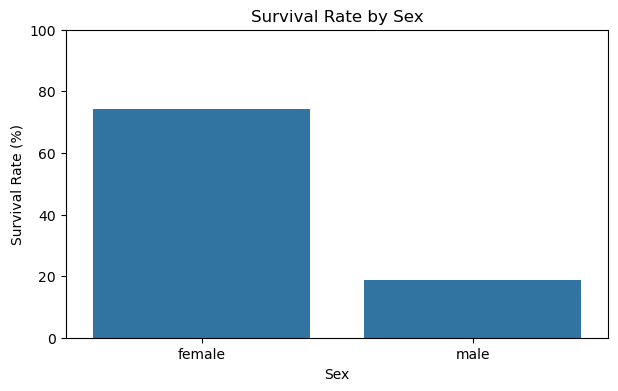

In [36]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=sex_survival,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

Female passengers had a much higher survival rate than male passengers.

In [37]:
def survival_barplot(data, x, title, order=None):
    survival = (
        data.groupby(x, observed=True)["survived"]
        .mean()
        .mul(100)
        .reset_index()
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=survival, x=x, y="survived", order=order)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Survival Rate (%)")
    plt.ylim(0, 100)
    plt.show()

### Question 2: Did survival rate differ by passenger class?

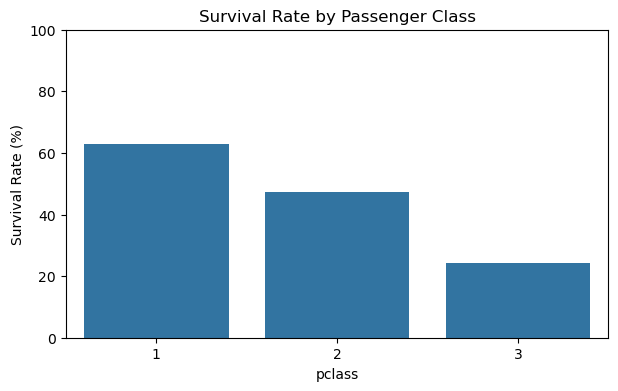

In [38]:
survival_barplot(df, "pclass", "Survival Rate by Passenger Class", order = [1, 2, 3])

First class passengers had the highest survival rate, while third class passengers had the lowest.

### Question 3: Did survival rate differ by age group?

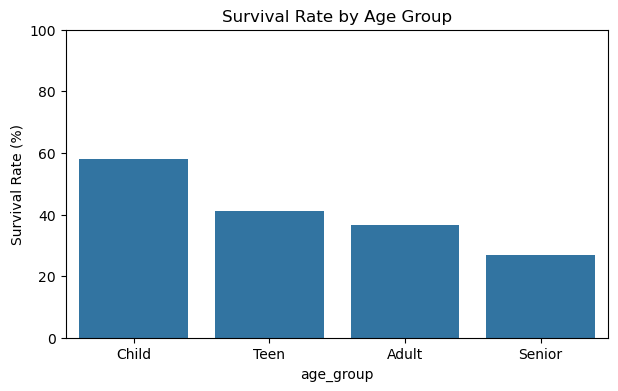

In [39]:
age_order = ["Child", "Teen", "Adult", "Senior"]

survival_barplot(
    df,
    "age_group",
    "Survival Rate by Age Group",
    order=age_order
)

Children had the highest survival rate, while seniors had the lowest.

### Question 4: Did survival rate differ by fare group?

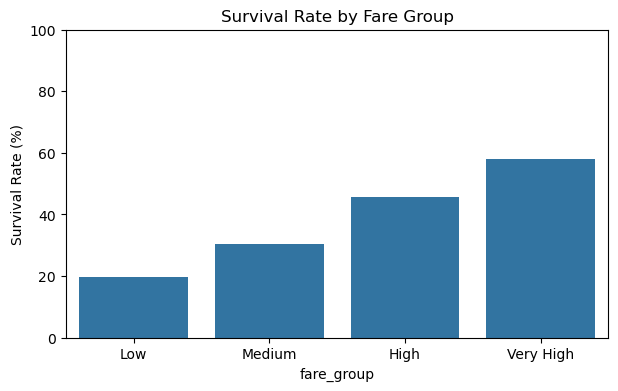

In [40]:
fare_order = ["Low", "Medium", "High", "Very High"]

survival_barplot(
    df,
    "fare_group",
    "Survival Rate by Fare Group",
    order=fare_order
)

Passengers in higher fare groups had higher survival rates. This may be related to passenger class, wealth, cabin location, and access to lifeboats.

### Question 5: Did survival rate differ by title group?

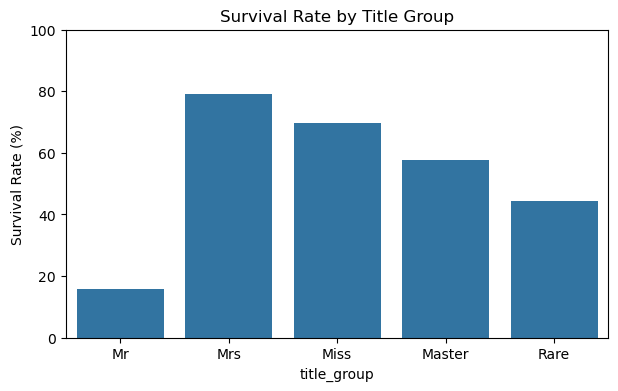

In [41]:
title_order = ["Mr", "Mrs", "Miss", "Master", "Rare"]

survival_barplot(
    df,
    "title_group",
    "Survival Rate by Title Group",
    order=title_order
)

Title groups show large survival differences, especially between Mr and female-associated titles such as Mrs and Miss.

### Question 6: Did passengers alone survive differently from passengers with family?

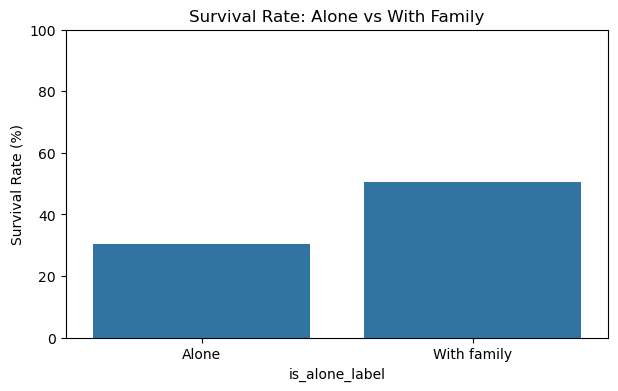

In [42]:
survival_barplot(
    df,
    "is_alone_label",
    "Survival Rate: Alone vs With Family",
    order=["Alone", "With family"]
)

Passengers traveling with family had a higher survival rate than passengers traveling alone.

### Age Distribution

This chart shows the overall age distribution of passengers.

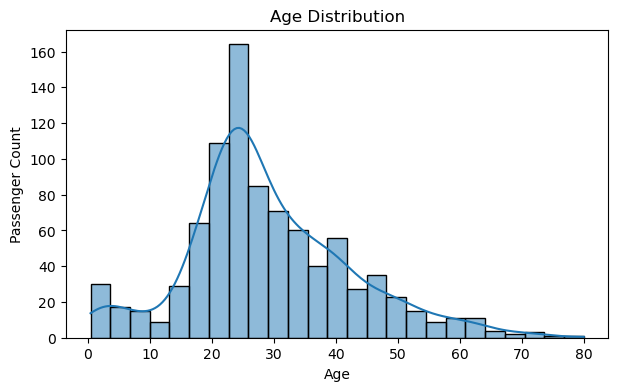

In [47]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=25, kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

Most passengers were adults, which matches the age_group counts from Day 2.

### Fare Distribution

This chart shows how passenger fares are distributed.

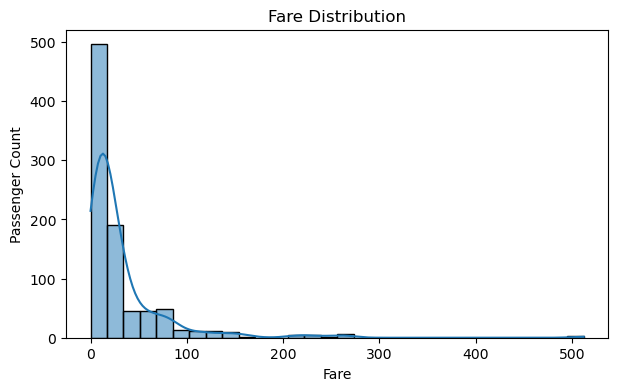

In [51]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="fare", bins=30, kde = True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")
plt.show()

Fare is highly right-skewed, meaning most passengers paid lower fares while a small number paid very high fares.

### Question 7: How do sex and passenger class interact in survival rate?

In [53]:
class_sex_survival = (
    df.groupby(["pclass", "sex"])["survived"]
    .mean()
    .mul(100)
    .reset_index()
)

class_sex_survival

,pclass,sex,survived
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


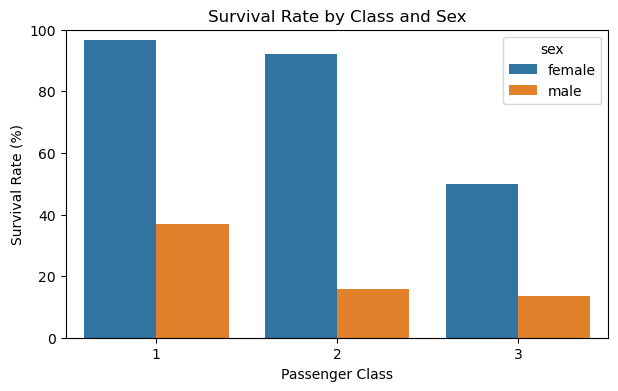

In [54]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=class_sex_survival,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

The sex-based survival difference remains visible across passenger classes, showing that both sex and class are important survival-related features.

In [55]:
df.to_csv("titanic_features.csv", index=False)